# Monitoramento de Drift e Simulacao Operacional

Este notebook demonstra a camada de monitoramento do projeto end-to-end de churn. O fluxo cobre a geracao de dados sinteticos, a inferencia com o pipeline vencedor, a comparacao entre um cenario baseline e um cenario com drift e a interpretacao completa dos alertas e graficos gerados.

De forma macro, o notebook responde quatro perguntas:

1. como gerar lotes sinteticos para testar a operacao da API e do monitoramento;
2. como o pipeline salvo reage a um cenario com mudanca no comportamento dos dados;
3. quais features mostram drift relevante segundo o PSI;
4. como traduzir esses sinais em uma recomendacao de investigacao e possivel retreinamento.

## Plano de implementacao

- carregar o modelo vencedor salvo e definir o schema bruto esperado;
- gerar um lote sintetico baseline a partir dos dados raw;
- gerar um lote driftado simulando piora operacional e menor engajamento;
- executar inferencia nos dois cenarios;
- calcular PSI e gerar alertas;
- salvar artefatos tabulares e visuais;
- interpretar os graficos de monitoramento com foco tecnico e operacional.

In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

sns.set_theme(style="whitegrid", palette="viridis")
matplotlib.use("Agg")
warnings.filterwarnings("ignore")

In [2]:
try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path.cwd()

ROOT_DIR = base_dir.parent
RAW_DATASET_PATH = ROOT_DIR / "data" / "raw" / "iranian_churn_telecom.parquet"
MODEL_BUNDLE_PATH = ROOT_DIR / "artifacts" / "models" / "best_churn_pipeline.joblib"
MODEL_METADATA_PATH = ROOT_DIR / "artifacts" / "models" / "best_churn_pipeline_metadata.json"
SYNTHETIC_DATA_DIR = ROOT_DIR / "data" / "synthetic"
MONITORING_ARTIFACTS_DIR = ROOT_DIR / "artifacts" / "monitoring"

RAW_INPUT_COLUMNS = [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "age_group",
    "tariff_plan",
    "status",
    "age",
    "customer_value",
]

INTEGER_COLUMNS = [column for column in RAW_INPUT_COLUMNS if column != "customer_value"]

SYNTHETIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
MONITORING_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()

def normalize_raw_columns(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data.columns = (
        data.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("__", "_", regex=False)
    )
    return data

def clip_and_cast(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    for column in INTEGER_COLUMNS:
        data[column] = data[column].round().clip(lower=0).astype(int)
    data["customer_value"] = data["customer_value"].clip(lower=0.0).round(4)
    return data

def generate_synthetic_baseline(raw_df: pd.DataFrame, n_samples: int = 500, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    sampled = raw_df.sample(n=n_samples, replace=True, random_state=random_state).reset_index(drop=True)
    data = sampled.copy()
    data["seconds_of_use"] = data["seconds_of_use"] * rng.normal(1.0, 0.12, n_samples)
    data["frequency_of_use"] = data["frequency_of_use"] * rng.normal(1.0, 0.10, n_samples)
    data["frequency_of_sms"] = data["frequency_of_sms"] * rng.normal(1.0, 0.18, n_samples)
    data["distinct_called_numbers"] = data["distinct_called_numbers"] * rng.normal(1.0, 0.10, n_samples)
    data["customer_value"] = data["customer_value"] * rng.normal(1.0, 0.08, n_samples)
    data["charge_amount"] = data["charge_amount"] * rng.normal(1.0, 0.08, n_samples)
    data["call_failure"] = data["call_failure"] + rng.poisson(0.2, n_samples)
    data["complains"] = np.where(
        rng.random(n_samples) < 0.06,
        np.minimum(data["complains"] + 1, 1),
        data["complains"],
    )
    return clip_and_cast(data)

def generate_synthetic_drift(baseline_df: pd.DataFrame, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state + 7)
    data = baseline_df.copy()
    data["call_failure"] = data["call_failure"] * rng.normal(1.8, 0.18, len(data)) + rng.poisson(2.0, len(data))
    data["complains"] = np.where(rng.random(len(data)) < 0.35, 1, data["complains"])
    data["frequency_of_use"] = data["frequency_of_use"] * rng.normal(0.72, 0.12, len(data))
    data["seconds_of_use"] = data["seconds_of_use"] * rng.normal(0.78, 0.10, len(data))
    data["frequency_of_sms"] = data["frequency_of_sms"] * rng.normal(0.84, 0.12, len(data))
    data["customer_value"] = data["customer_value"] * rng.normal(0.85, 0.06, len(data))
    data["charge_amount"] = data["charge_amount"] * rng.normal(1.12, 0.05, len(data))
    data["subscription_length"] = data["subscription_length"] * rng.normal(0.88, 0.08, len(data))
    return clip_and_cast(data)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    eps = 1e-6
    data["avg_seconds_per_call"] = data["seconds_of_use"] / (data["frequency_of_use"] + eps)
    data["sms_per_call"] = data["frequency_of_sms"] / (data["frequency_of_use"] + eps)
    data["calls_per_contact"] = data["frequency_of_use"] / (data["distinct_called_numbers"] + eps)
    data["contact_diversity_ratio"] = data["distinct_called_numbers"] / (data["frequency_of_use"] + eps)
    data["call_failure_rate"] = data["call_failure"] / (data["frequency_of_use"] + data["call_failure"] + eps)
    data["usage_per_month"] = data["seconds_of_use"] / (data["subscription_length"] + eps)
    data["calls_per_month"] = data["frequency_of_use"] / (data["subscription_length"] + eps)
    data["sms_per_month"] = data["frequency_of_sms"] / (data["subscription_length"] + eps)
    data["value_per_month"] = data["customer_value"] / (data["subscription_length"] + eps)
    data["value_per_call"] = data["customer_value"] / (data["frequency_of_use"] + eps)
    data["complaint_status_interaction"] = data["complains"] * data["status"]
    data["charge_value_gap"] = data["customer_value"] - data["charge_amount"]
    data["tenure_age_ratio"] = data["subscription_length"] / (data["age"] + eps)
    data["usage_value_efficiency"] = data["seconds_of_use"] / (data["customer_value"] + eps)
    return data

def validate_input_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        raise ValueError("The input dataframe is empty.")
    missing_columns = [column for column in RAW_INPUT_COLUMNS if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {', '.join(missing_columns)}")
    data = df.loc[:, RAW_INPUT_COLUMNS].copy()
    if data.isnull().any().any():
        null_columns = data.columns[data.isnull().any()].tolist()
        raise ValueError(f"Null values detected in required columns: {', '.join(null_columns)}")
    for column in RAW_INPUT_COLUMNS:
        data[column] = pd.to_numeric(data[column], errors="raise")
        if (data[column] < 0).any():
            raise ValueError(f"Column {column} contains negative values.")
    return data

def load_model_bundle(bundle_path: Path = MODEL_BUNDLE_PATH) -> dict:
    return joblib.load(bundle_path)

def predict_dataframe(raw_input_df: pd.DataFrame, model_bundle: dict, source: str) -> pd.DataFrame:
    clean_df = validate_input_dataframe(raw_input_df)
    engineered_df = engineer_features(clean_df)
    feature_df = engineered_df.loc[:, model_bundle["feature_columns"]].copy()
    threshold = float(model_bundle.get("threshold", 0.50))
    probabilities = model_bundle["pipeline"].predict_proba(feature_df)[:, 1]
    predicted_labels = (probabilities >= threshold).astype(int)
    return pd.DataFrame(
        {
            "prediction_timestamp_utc": [utc_now_iso()] * len(feature_df),
            "request_id": [str(uuid4()) for _ in range(len(feature_df))],
            "source": [source] * len(feature_df),
            "model_name": [model_bundle["model_name"]] * len(feature_df),
            "model_version": [model_bundle.get("model_version", "legacy")] * len(feature_df),
            "score": probabilities,
            "predicted_label": predicted_labels,
            "threshold": [threshold] * len(feature_df),
        }
    )

def calculate_psi(reference: pd.Series, current: pd.Series, bins: int = 10) -> float:
    reference_clean = pd.Series(reference).dropna().astype(float)
    current_clean = pd.Series(current).dropna().astype(float)
    breakpoints = np.unique(np.quantile(reference_clean, np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 3:
        return 0.0
    reference_hist, _ = np.histogram(reference_clean, bins=breakpoints)
    current_hist, _ = np.histogram(current_clean, bins=breakpoints)
    reference_ratio = np.clip(reference_hist / max(reference_hist.sum(), 1), 1e-6, None)
    current_ratio = np.clip(current_hist / max(current_hist.sum(), 1), 1e-6, None)
    return float(np.sum((current_ratio - reference_ratio) * np.log(current_ratio / reference_ratio)))

def classify_drift(psi: float) -> str:
    if psi >= 0.20:
        return "high"
    if psi >= 0.10:
        return "moderate"
    return "low"

def compute_monitoring_snapshot(reference_df: pd.DataFrame, current_df: pd.DataFrame, dataset_label: str) -> pd.DataFrame:
    rows = []
    run_id = str(uuid4())
    observed_at_utc = utc_now_iso()
    for column in reference_df.columns:
        psi = calculate_psi(reference_df[column], current_df[column])
        rows.append(
            {
                "run_id": run_id,
                "observed_at_utc": observed_at_utc,
                "dataset_label": dataset_label,
                "feature_name": column,
                "reference_mean": float(reference_df[column].mean()),
                "current_mean": float(current_df[column].mean()),
                "reference_std": float(reference_df[column].std()),
                "current_std": float(current_df[column].std()),
                "reference_missing_rate": float(reference_df[column].isna().mean()),
                "current_missing_rate": float(current_df[column].isna().mean()),
                "psi": float(psi),
                "drift_severity": classify_drift(psi),
            }
        )
    return pd.DataFrame(rows)

def build_drift_alerts(snapshot_df: pd.DataFrame, prediction_rate_reference: float, prediction_rate_current: float) -> pd.DataFrame:
    rows = []
    for _, row in snapshot_df.iterrows():
        if row["drift_severity"] == "low":
            continue
        rows.append(
            {
                "feature_name": row["feature_name"],
                "psi": float(row["psi"]),
                "severity": row["drift_severity"],
                "message": f"Feature {row['feature_name']} shows {row['drift_severity']} drift with PSI={row['psi']:.4f}.",
            }
        )
    delta = prediction_rate_current - prediction_rate_reference
    if abs(delta) >= 0.08:
        rows.append(
            {
                "feature_name": "predicted_churn_rate",
                "psi": np.nan,
                "severity": "high" if abs(delta) >= 0.15 else "moderate",
                "message": f"Predicted churn rate changed materially. Delta={delta:.4f}.",
            }
        )
    return pd.DataFrame(rows)

def plot_drift_summary(snapshot_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = snapshot_df.sort_values("psi", ascending=True).copy()
    severity_palette = {"low": "#7fb069", "moderate": "#f2c14e", "high": "#d95d39"}
    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["feature_name"], plot_df["psi"], color=plot_df["drift_severity"].map(severity_palette))
    plt.axvline(0.10, color="#f2c14e", linestyle="--", linewidth=1.2, label="PSI moderado")
    plt.axvline(0.20, color="#d95d39", linestyle="--", linewidth=1.2, label="PSI alto")
    plt.xlabel("Population Stability Index (PSI)")
    plt.ylabel("")
    plt.title("Resumo visual do drift por feature")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()

def plot_prediction_rate_shift(prediction_rate_reference: float, prediction_rate_current: float, output_path: Path) -> None:
    rate_df = pd.DataFrame(
        {
            "dataset": ["baseline", "drifted"],
            "predicted_churn_rate": [prediction_rate_reference, prediction_rate_current],
        }
    )
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(
        data=rate_df,
        x="dataset",
        y="predicted_churn_rate",
        hue="dataset",
        palette={"baseline": "#4c78a8", "drifted": "#d95d39"},
        dodge=False,
        legend=False,
    )
    ax.bar_label(ax.containers[0], fmt="%.2f")
    plt.ylim(0, max(rate_df["predicted_churn_rate"].max() * 1.2, 0.1))
    plt.xlabel("")
    plt.ylabel("Predicted churn rate")
    plt.title("Mudanca da taxa prevista de churn")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()

def plot_alerted_feature_distributions(reference_df: pd.DataFrame, current_df: pd.DataFrame, snapshot_df: pd.DataFrame, output_path: Path) -> None:
    alerted_features = snapshot_df.loc[snapshot_df["drift_severity"] != "low", "feature_name"].tolist()[:4]
    if not alerted_features:
        return
    fig, axes = plt.subplots(len(alerted_features), 1, figsize=(10, max(3.5 * len(alerted_features), 4)), squeeze=False)
    for ax, feature_name in zip(axes.flatten(), alerted_features):
        sns.kdeplot(reference_df[feature_name], ax=ax, label="baseline", fill=True, alpha=0.25, color="#4c78a8")
        sns.kdeplot(current_df[feature_name], ax=ax, label="drifted", fill=True, alpha=0.25, color="#d95d39")
        feature_psi = snapshot_df.loc[snapshot_df["feature_name"] == feature_name, "psi"].iloc[0]
        ax.set_title(f"{feature_name} | PSI={feature_psi:.3f}")
        ax.set_xlabel("")
        ax.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


## Geracao dos dados sinteticos e contexto do experimento

O monitoramento precisa de um lote de referencia e de um lote atual para comparacao. Neste notebook, ambos sao sinteticos, mas preservam o schema bruto esperado pela inferencia.

- o **baseline** representa um lote operacional parecido com o comportamento historico observado;
- o **drifted** representa um lote em que a qualidade operacional piora, as reclamacoes aumentam e o engajamento diminui.

Esse desenho e importante porque cria um cenario controlado para testar a camada de observabilidade do modelo, sem depender de dados reais futuros.

In [4]:
raw_df = normalize_raw_columns(pd.read_parquet(RAW_DATASET_PATH))
baseline_df = generate_synthetic_baseline(raw_df, n_samples=500, random_state=42).loc[:, RAW_INPUT_COLUMNS]
drift_df = generate_synthetic_drift(baseline_df, random_state=42).loc[:, RAW_INPUT_COLUMNS]

baseline_path = SYNTHETIC_DATA_DIR / "api_test_baseline.parquet"
drift_path = SYNTHETIC_DATA_DIR / "api_test_drifted.parquet"
baseline_df.to_parquet(baseline_path, index=False)
drift_df.to_parquet(drift_path, index=False)

display(Markdown("### Amostra do lote baseline"))
display(baseline_df.head())
display(Markdown("### Amostra do lote driftado"))
display(drift_df.head())

### Amostra do lote baseline

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value
0,13,0,39,1,6870,120,15,11,3,1,1,30,317.4516
1,0,0,12,0,1147,20,10,8,2,1,1,25,103.4397
2,2,0,33,1,7129,87,11,25,4,1,1,45,202.6501
3,11,0,15,0,6775,115,87,41,1,2,1,15,786.8047
4,15,0,27,1,1172,27,26,15,2,1,1,25,166.4814


### Amostra do lote driftado

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value
0,30,0,32,1,4433,96,12,11,3,1,1,30,245.7205
1,0,0,10,0,790,15,8,8,2,1,1,25,86.3441
2,5,1,31,1,5603,69,8,25,4,1,1,45,173.2237
3,18,0,13,0,5157,85,61,41,1,2,1,15,609.1862
4,27,0,25,1,1011,18,24,15,2,1,1,25,135.5094


## Inferencia com o pipeline vencedor

A proxima etapa e submeter os dois lotes ao pipeline vencedor salvo em `artifacts/models`. Isso permite verificar se a mudanca no comportamento dos dados se traduz em mudanca nas probabilidades previstas de churn.

In [5]:
model_bundle = load_model_bundle()
model_metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8"))

baseline_predictions = predict_dataframe(baseline_df, model_bundle=model_bundle, source="synthetic_baseline")
drift_predictions = predict_dataframe(drift_df, model_bundle=model_bundle, source="synthetic_drift")

prediction_summary_df = pd.DataFrame([
    {
        "dataset": "baseline",
        "predicted_churn_rate": float(baseline_predictions["predicted_label"].mean()),
        "average_score": float(baseline_predictions["score"].mean()),
    },
    {
        "dataset": "drifted",
        "predicted_churn_rate": float(drift_predictions["predicted_label"].mean()),
        "average_score": float(drift_predictions["score"].mean()),
    },
])

prediction_summary_df

,dataset,predicted_churn_rate,average_score
0,baseline,0.18,0.185907
1,drifted,0.41,0.414627


A tabela compara o comportamento médio das previsões do modelo em dois cenários:

- `baseline`: cenário sintético mais próximo da distribuição original de referência;
- `drifted`: cenário sintético com alteração nas distribuições das variáveis, simulando drift de dados.

Significado das colunas

**`predicted_churn_rate`**: Representa a proporção de registros que o modelo classificou como churn, ou seja, casos em que `predicted_label = 1`.

- `0.18` no cenário `baseline`: 18% dos clientes foram classificados como churn;
- `0.41` no cenário `drifted`: 41% dos clientes foram classificados como churn.

**`average_score`** : Representa a média das probabilidades previstas de churn (`score`) para o conjunto avaliado.

- `0.185907` no cenário `baseline`: risco médio previsto de churn de aproximadamente `18,6%`;
- `0.414627` no cenário `drifted`: risco médio previsto de churn de aproximadamente `41,5%`.

Interpretação prática

No cenário `drifted`, o modelo passou a enxergar uma parcela muito maior de clientes como arriscada. Esse comportamento sugere que a nova massa de dados foi deslocada para uma região mais próxima dos padrões que o modelo aprendeu historicamente como associados ao churn.

Em termos operacionais, esse é exatamente o tipo de sinal que justifica um alerta de monitoramento, pois pode indicar:

- uma mudança real no comportamento dos clientes;
- uma deterioração do contexto operacional;
- ou um desvio importante em relação ao padrão de dados usado no treinamento.

### Leitura executiva

A comparação mostra que, no cenário driftado, tanto a taxa prevista de churn quanto o score médio aumentaram de forma relevante em relação ao baseline. Isso indica que os novos dados passaram a se parecer mais com perfis historicamente associados à evasão, o que reforça a necessidade de acompanhamento contínuo e possível revisão do modelo ao longo do tempo. Esse aumento, porém, não deve ser interpretado como melhora do modelo: sem `y_true` para esse novo lote, não é possível saber se o modelo ficou mais sensível de forma correta ou se começou a superestimar churn.


## Monitoramento e artefatos

Agora o notebook calcula o snapshot de drift, gera alertas e salva os artefatos visuais e tabulares na pasta `artifacts/monitoring/`. O objetivo e aproximar o experimento de um fluxo operacional de verdade, em que um lote novo e comparado contra uma referencia historica.

In [6]:
snapshot_df = compute_monitoring_snapshot(baseline_df, drift_df, dataset_label="synthetic_api_drift_demo")
alerts_df = build_drift_alerts(
    snapshot_df,
    prediction_rate_reference=float(baseline_predictions["predicted_label"].mean()),
    prediction_rate_current=float(drift_predictions["predicted_label"].mean()),
)

drift_overview_plot_path = MONITORING_ARTIFACTS_DIR / "drift_overview.png"
prediction_shift_plot_path = MONITORING_ARTIFACTS_DIR / "predicted_churn_rate_shift.png"
alerted_features_plot_path = MONITORING_ARTIFACTS_DIR / "alerted_feature_distributions.png"
snapshot_path = MONITORING_ARTIFACTS_DIR / "drift_summary.csv"
alerts_path = MONITORING_ARTIFACTS_DIR / "drift_alerts.csv"
report_path = MONITORING_ARTIFACTS_DIR / "drift_report.json"

snapshot_df.to_csv(snapshot_path, index=False)
alerts_df.to_csv(alerts_path, index=False)
report = {
    "run_id": snapshot_df["run_id"].iloc[0],
    "dataset_label": "synthetic_api_drift_demo",
    "observed_at_utc": snapshot_df["observed_at_utc"].iloc[0],
    "features_with_moderate_or_high_drift": snapshot_df.loc[snapshot_df["drift_severity"] != "low", "feature_name"].tolist(),
    "alert_count": int(len(alerts_df)),
    "prediction_rate_reference": float(baseline_predictions["predicted_label"].mean()),
    "prediction_rate_current": float(drift_predictions["predicted_label"].mean()),
}
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=True), encoding="utf-8")

plot_drift_summary(snapshot_df, drift_overview_plot_path)
plot_prediction_rate_shift(
    float(baseline_predictions["predicted_label"].mean()),
    float(drift_predictions["predicted_label"].mean()),
    prediction_shift_plot_path,
)
plot_alerted_feature_distributions(baseline_df, drift_df, snapshot_df, alerted_features_plot_path)

display(Markdown("### Snapshot de drift"))
display(snapshot_df.sort_values("psi", ascending=False).round(4))
display(Markdown("### Alertas gerados"))
display(alerts_df.round(4))
display(Markdown("### Resumo executivo do monitoramento"))
report

### Snapshot de drift

,run_id,observed_at_utc,dataset_label,feature_name,reference_mean,current_mean,reference_std,current_std,reference_missing_rate,current_missing_rate,psi,drift_severity
0,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,call_failure,7.5400,15.4900,6.9959,12.7382,0.0,0.0,0.6703,high
2,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,subscription_length,32.3800,28.4360,8.7208,8.0196,0.0,0.0,0.6146,high
5,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,frequency_of_use,71.0220,50.9260,56.7472,41.4528,0.0,0.0,0.1913,moderate
4,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,seconds_of_use,4458.8760,3483.3180,4090.0178,3226.1589,0.0,0.0,0.0993,low
12,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,customer_value,515.9855,438.9933,574.6849,492.1316,0.0,0.0,0.0421,low
6,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,frequency_of_sms,84.6680,71.3440,132.2798,112.5255,0.0,0.0,0.0282,low
3,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,charge_amount,0.8900,0.9220,1.3437,1.4752,0.0,0.0,0.0000,low
1,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,complains,0.0960,0.4200,0.2949,0.4941,0.0,0.0,0.0000,low
7,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,distinct_called_numbers,23.5380,23.5380,16.6564,16.6564,0.0,0.0,0.0000,low
8,6f705ea7-10f2-4006-9714-74be4ae02f5a,2026-03-13T22:26:03+00:00,synthetic_api_drift_demo,age_group,2.8040,2.8040,0.8850,0.8850,0.0,0.0,0.0000,low


### Alertas gerados

,feature_name,psi,severity,message
0,call_failure,0.6703,high,Feature call_failure shows high drift with PSI...
1,subscription_length,0.6146,high,Feature subscription_length shows high drift w...
2,frequency_of_use,0.1913,moderate,Feature frequency_of_use shows moderate drift ...
3,predicted_churn_rate,NaN,high,Predicted churn rate changed materially. Delta...


### Resumo executivo do monitoramento

{'run_id': '6f705ea7-10f2-4006-9714-74be4ae02f5a',
 'dataset_label': 'synthetic_api_drift_demo',
 'observed_at_utc': '2026-03-13T22:26:03+00:00',
 'features_with_moderate_or_high_drift': ['call_failure',
  'subscription_length',
  'frequency_of_use'],
 'alert_count': 4,
 'prediction_rate_reference': 0.18,
 'prediction_rate_current': 0.41}

## Grafico 1: resumo visual do drift por feature

**O que o grafico mostra:** um ranking de `PSI` por feature, com linhas de referencia para drift moderado (`0.10`) e alto (`0.20`). Cada barra representa o quanto a distribuicao da feature se deslocou do baseline para o lote atual.

**Por que ele e importante:** este e o grafico mais direto para triagem operacional. Ele permite localizar rapidamente quais variaveis mudaram mais e quais merecem investigacao prioritaria. Em vez de inspecionar dezenas de colunas individualmente, o time consegue ver um ranking consolidado de severidade.

**Como interpretar os insights:**

- features com `PSI < 0.10` tendem a ser estaveis e, neste contexto, nao justificam alarme imediato;
- features entre `0.10` e `0.20` merecem monitoramento reforcado, porque indicam deslocamento relevante;
- features acima de `0.20` sugerem mudanca material no comportamento do lote atual e costumam ser candidatas naturais a investigacao de negocio, qualidade de dados ou revisao do modelo.

Neste experimento, o grafico ajuda a mostrar que o drift nao esta distribuido de forma uniforme: ele se concentra em variaveis de qualidade operacional e engajamento, exatamente como foi planejado no cenario sintetico.

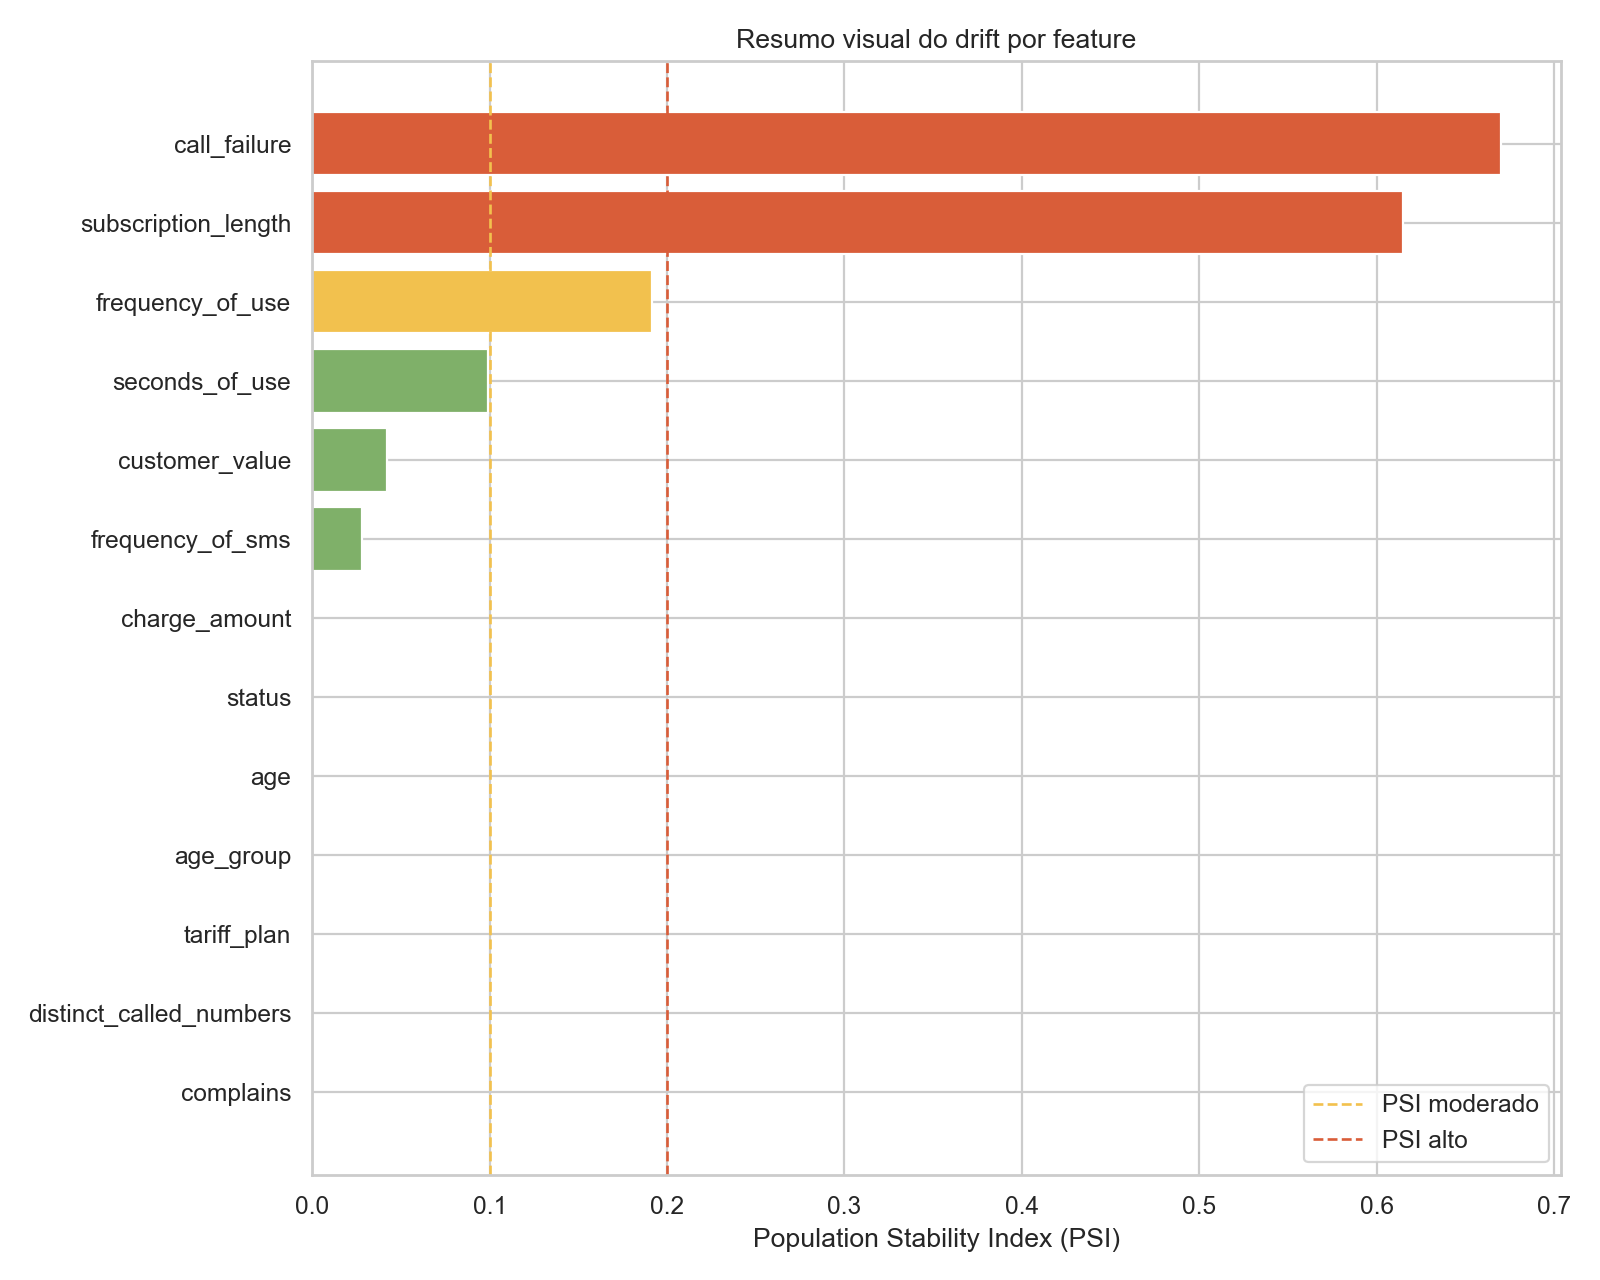

In [7]:
display(Image(filename=str(drift_overview_plot_path)))

## Grafico 2: mudanca da taxa prevista de churn

**O que o grafico mostra:** a comparacao entre a taxa prevista de churn no lote baseline e no lote driftado. Aqui o foco nao esta em uma feature isolada, mas no comportamento agregado da saida do modelo.

**Por que ele e importante:** mesmo que o drift em entrada pareca pontual, o que mais importa operacionalmente e se a saida do modelo mudou de forma relevante. Uma subida material da taxa prevista de churn pode significar uma mudanca real no comportamento dos clientes, um problema de dados ou degradacao do modelo em um novo regime operacional. Isso nao significa, por si so, que o modelo melhorou.

**Como interpretar os insights:**

- se a taxa prevista se mantem estavel, o modelo provavelmente continua operando em um cenario proximo ao de treino;
- se a taxa prevista sobe muito, como neste experimento, isso reforca que o deslocamento das features esta afetando o risco previsto e nao apenas a distribuicao dos inputs;
- esse tipo de grafico e especialmente util para stakeholders, porque traduz o drift tecnico em um impacto operacional mais facil de comunicar.

Neste caso, a taxa prevista de churn sobe de forma clara no cenario driftado, o que justifica o alerta adicional para investigacao e possivel preparacao de um ciclo de retreinamento. Sem os rotulos reais desse novo lote (`y_true`), nao e possivel concluir se o modelo passou a acertar mais ou se apenas ficou mais agressivo nas previsoes. Em outras palavras, ainda nao sabemos se ele ficou mais sensivel de forma correta ou se comecou a superestimar churn.

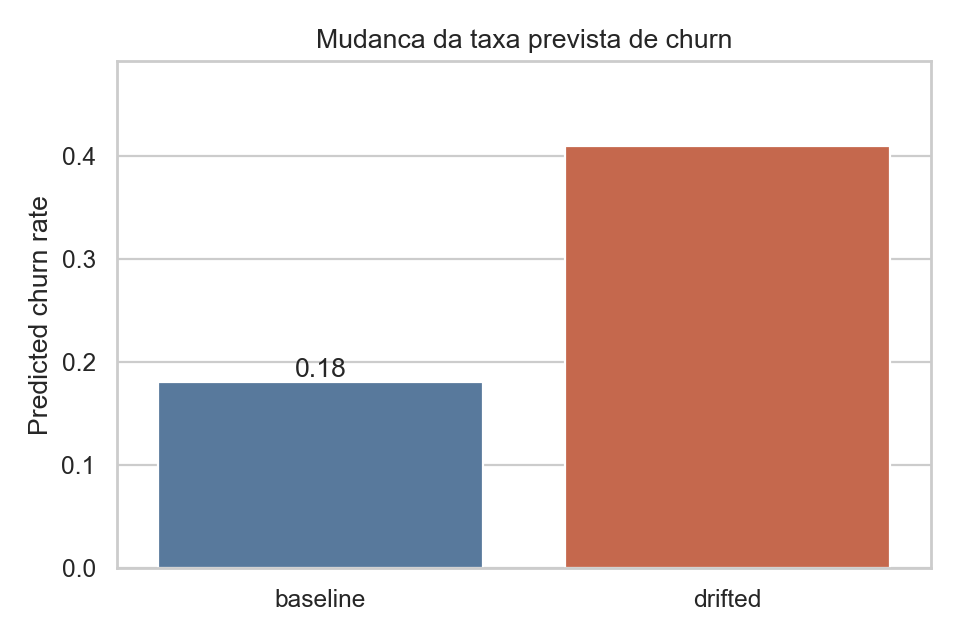

In [8]:
display(Image(filename=str(prediction_shift_plot_path)))

## Grafico 3: distribuicoes das features com alerta

**O que o grafico mostra:** a sobreposicao das distribuicoes `baseline` e `drifted` para as principais features com alerta. Cada painel mostra como a massa da distribuicao se deslocou entre os dois cenarios.

**Por que ele e importante:** enquanto o PSI resume o drift em um unico numero, esse grafico mostra *como* a mudanca aconteceu. Isso ajuda a entender se o deslocamento veio de aumento da media, mudanca de dispersao, concentracao em cauda ou combinacoes desses efeitos.

**Como interpretar os insights:**

- quando as curvas ficam bem separadas, o drift e mais facil de defender tecnicamente;
- quando a curva driftada se desloca para piores valores operacionais, isso reforca a narrativa de que o risco previsto de churn esta reagindo a um problema plausivel de negocio;
- esse grafico e especialmente util para explicar o alerta em reviews tecnicos, porque ele conecta o numero do PSI a um comportamento concreto da feature.

Neste notebook, as distribui??es das features alertadas ajudam a confirmar que o cenario driftado nao e apenas um ruido estatistico: ele foi constru?do para representar piora de qualidade e queda de engajamento, e o grafico torna isso visivel.

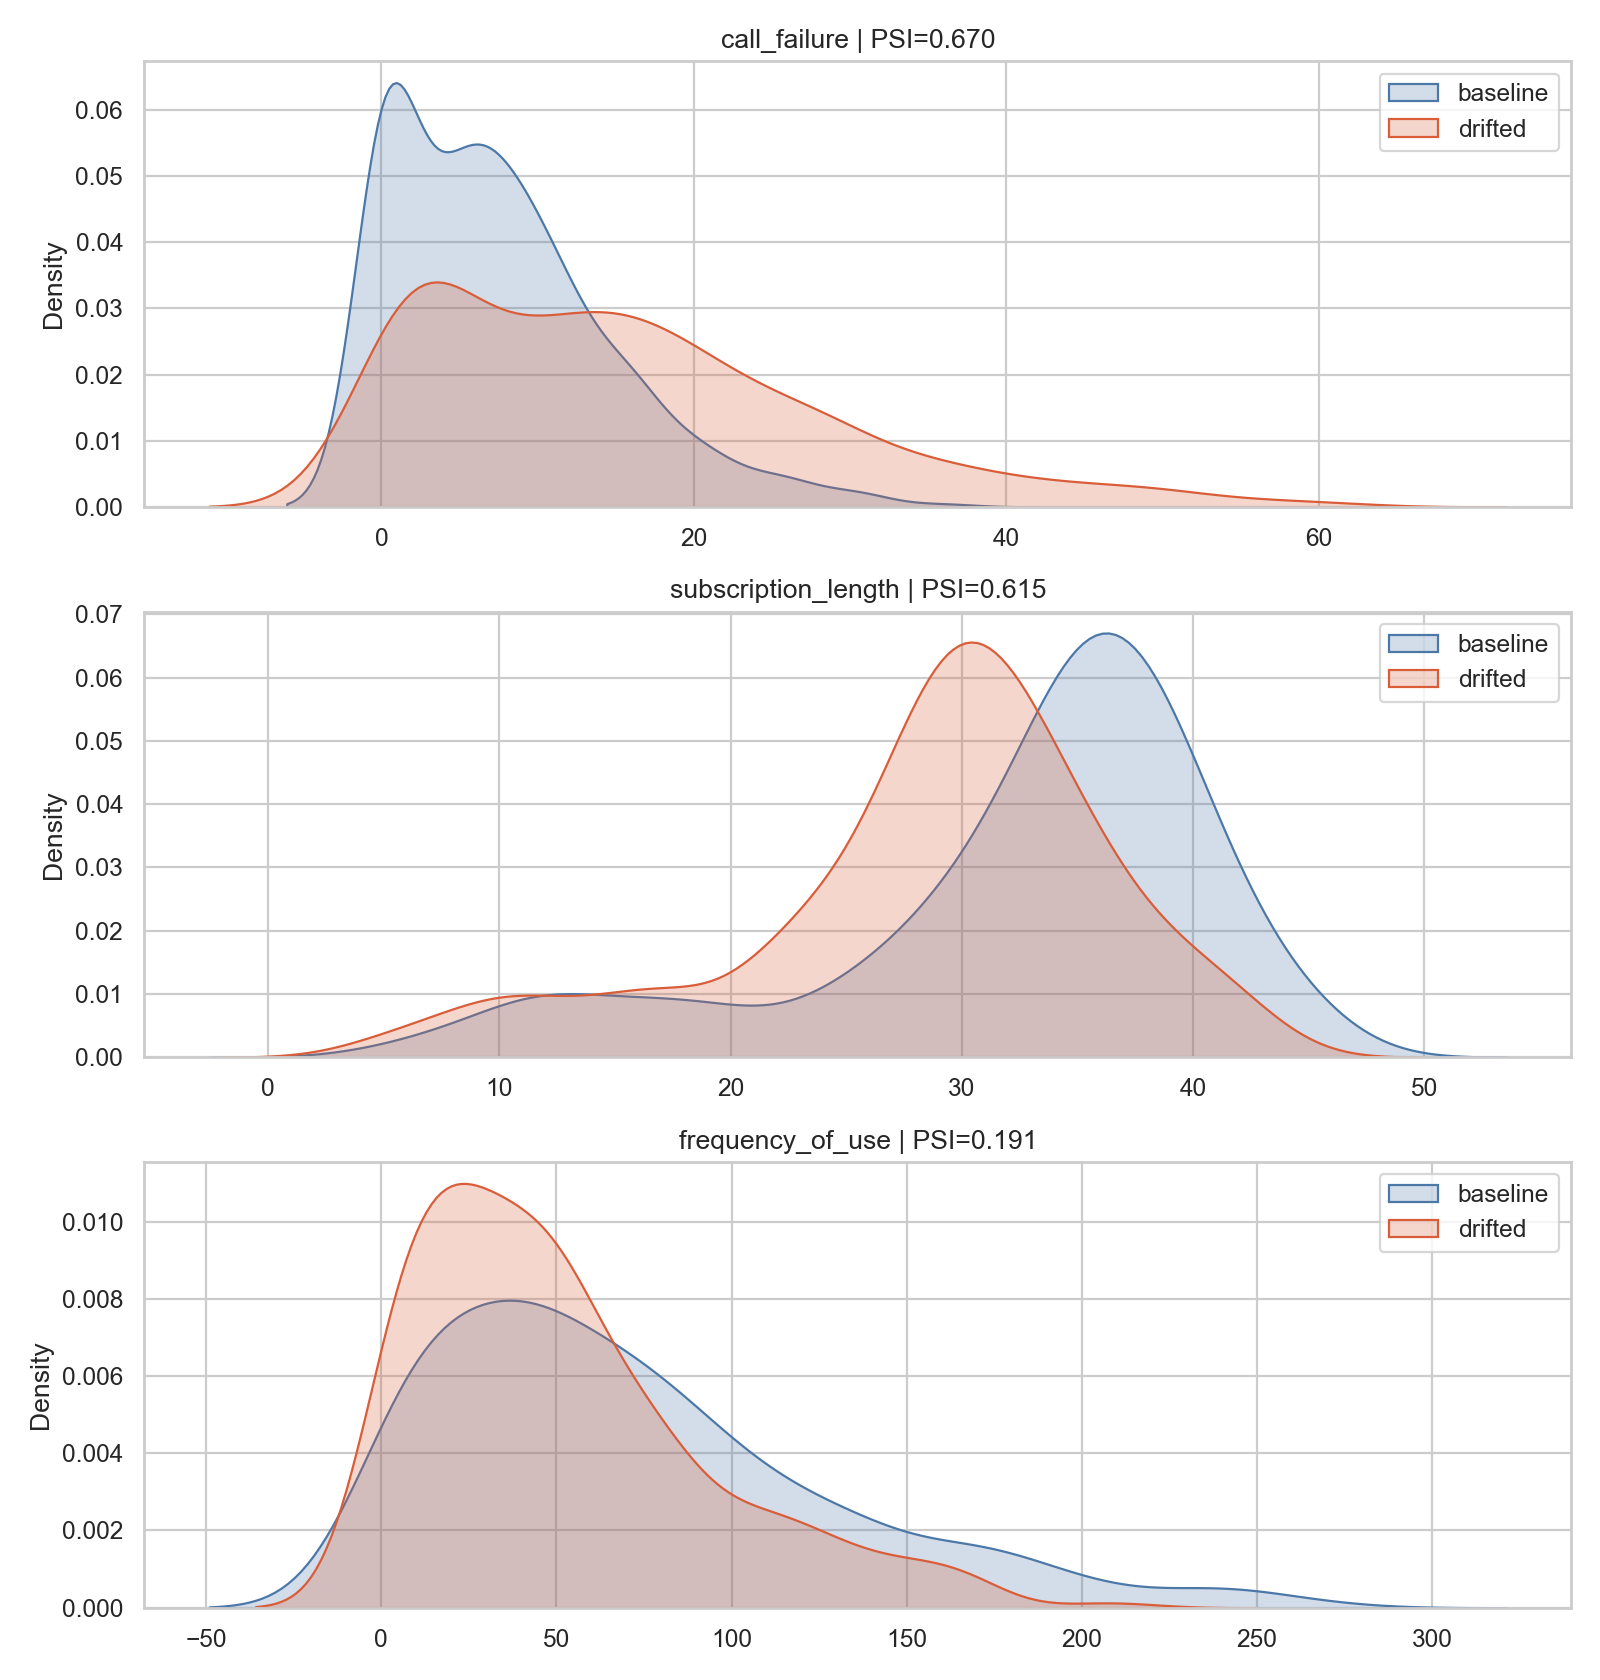

In [9]:
display(Image(filename=str(alerted_features_plot_path)))

## Conclusao

O experimento confirma que a camada de monitoramento esta funcionando como esperado para um cenario de portfolio orientado a MLOps. O fluxo conseguiu:

- gerar lotes sinteticos coerentes com o schema bruto da inferencia;
- aplicar o pipeline salvo do modelo vencedor em dados novos;
- detectar drift relevante por feature via PSI;
- sinalizar mudanca na taxa prevista de churn;
- transformar esses sinais em artefatos tabulares e visuais reutilizaveis.

Na pratica, este notebook nao substitui o processo de retreinamento, mas demonstra o passo anterior mais importante: saber quando a operacao mudou o suficiente para justificar investigacao e possivel revisao do modelo.